<a href="https://colab.research.google.com/github/farahwadya/Car-insurance-claims-prediction/blob/main/car_insurance_claim_intelligent_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# import packages

In [ ]:
import pandas as pd
#split to train and test model
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn import set_config
set_config(transform_output='pandas')
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tensorflow.keras import metrics
from tensorflow import keras
from keras.layers import Dense
from sklearn.ensemble import RandomForestClassifier
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# custome function

In [ ]:
def plot_roc(model, X_test, y_test, name):

    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

    plt.legend()
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")

In [ ]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):

  # Training predictions
  y_train_pred_proba = model.predict(X_train)
  y_train_pred = (y_train_pred_proba >= 0.5).astype(int)

  # Test predictions
  y_test_pred_proba = model.predict(X_test)
  y_test_pred = (y_test_pred_proba >= 0.5).astype(int)

  # Metrics
  results_train = classification_metrics(
      y_train, y_train_pred,
      output_dict=True, figsize=figsize,
      colorbar=colorbar, cmap=cmap_train,
      label='Training Data'
  )
  print()

  results_test = classification_metrics(
      y_test, y_test_pred,
      output_dict=True, figsize=figsize,
      colorbar=colorbar, cmap=cmap_test,
      label='Test Data'
  )

  if output_dict:
      return {'train': results_train, 'test': results_test}

In [ ]:
fpath='/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Car_Insurance_Claim.csv'
df=pd.read_csv(fpath)
df.head()

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [ ]:
df.describe()

,ID,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
count,10000.000000,9018.000000,10000.000000,10000.000000,10000.000000,10000.000000,9043.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,500521.906800,0.515813,0.697000,0.498200,0.688800,19864.548400,11697.003207,1.482900,0.23920,1.056300,0.313300
std,290030.768758,0.137688,0.459578,0.500022,0.463008,18915.613855,2818.434528,2.241966,0.55499,1.652454,0.463858
min,101.000000,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,0.417191,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,0.525033,1.000000,0.000000,1.000000,10238.000000,12000.000000,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,0.618312,1.000000,1.000000,1.000000,32765.000000,14000.000000,2.000000,0.00000,2.000000,1.000000
max,999976.000000,0.960819,1.000000,1.000000,1.000000,92101.000000,22000.000000,22.000000,6.00000,15.000000,1.000000


In [ ]:
df.shape

(10000, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_VIOLATIONS  10000 non-null  

In [ ]:
df['OUTCOME'].unique()

array([0., 1.])

# Data cleaning

## Data type and inconsistent

In [ ]:
print(df.dtypes)

ID                       int64
AGE                     object
GENDER                  object
RACE                    object
DRIVING_EXPERIENCE      object
EDUCATION               object
INCOME                  object
CREDIT_SCORE           float64
VEHICLE_OWNERSHIP      float64
VEHICLE_YEAR            object
MARRIED                float64
CHILDREN               float64
POSTAL_CODE              int64
ANNUAL_MILEAGE         float64
VEHICLE_TYPE            object
SPEEDING_VIOLATIONS      int64
DUIS                     int64
PAST_ACCIDENTS           int64
OUTCOME                float64
dtype: object


### Age

In [ ]:
df['AGE'].unique()

array(['65+', '16-25', '26-39', '40-64'], dtype=object)

In [ ]:
age_map = {
    '16-25': 'Young',
    '26-39': 'Adult',
    '40-64': 'Middle-aged',
    '65+': 'Old'
}
df['AGE'] = df['AGE'].map(age_map)

In [ ]:
df['AGE'].unique()

array(['Old', 'Young', 'Adult', 'Middle-aged'], dtype=object)

In [ ]:
df['GENDER'].unique()

array(['female', 'male'], dtype=object)

In [ ]:
df['RACE'].unique()

array(['majority', 'minority'], dtype=object)

In [ ]:
df['DRIVING_EXPERIENCE'].unique()

array(['0-9y', '10-19y', '20-29y', '30y+'], dtype=object)

In [ ]:
df['EDUCATION'].unique()

array(['high school', 'none', 'university'], dtype=object)

In [ ]:
df['INCOME'].unique()

array(['upper class', 'poverty', 'working class', 'middle class'],
      dtype=object)

In [ ]:
df['VEHICLE_YEAR'].unique()

array(['after 2015', 'before 2015'], dtype=object)

In [ ]:
df['VEHICLE_TYPE'].unique()

array(['sedan', 'sports car'], dtype=object)

### Driving experience

In [ ]:
experience_map = {
    '0-9y': 'Novice (0-9y)',
    '10-19y': 'Intermediate (10-19y)',
    '20-29y': 'Experienced (20-29y)',
    '30y+': 'Expert (30y+)'
}

df['DRIVING_EXPERIENCE'] = df['DRIVING_EXPERIENCE'].map(experience_map)

## null values

In [ ]:
df.isna().sum()

,0
ID,0
AGE,0
GENDER,0
RACE,0
DRIVING_EXPERIENCE,0
EDUCATION,0
INCOME,0
CREDIT_SCORE,982
VEHICLE_OWNERSHIP,0
VEHICLE_YEAR,0


## duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

# Exploration

In [ ]:
df.head()

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,Old,female,majority,Novice (0-9y),high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,Young,male,majority,Novice (0-9y),none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,Young,female,majority,Novice (0-9y),high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,Young,male,majority,Novice (0-9y),university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,Adult,male,majority,Intermediate (10-19y),none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


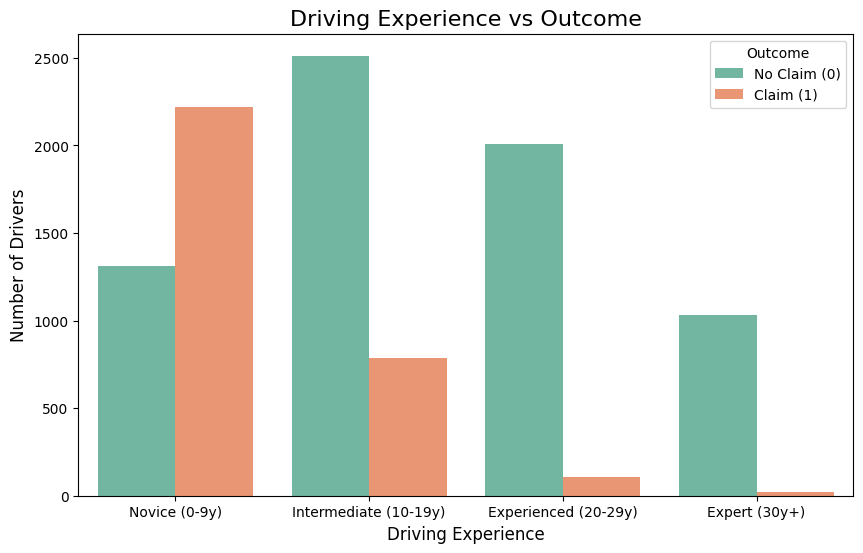

In [ ]:

# Set the figure size
plt.figure(figsize=(10,6))

# Plot countplot: Driving Experience vs Outcome, colored by OUTCOME
sns.countplot( data=df, x='DRIVING_EXPERIENCE',hue='OUTCOME',palette='Set2',
    dodge=True)

# Add title and axis labels
plt.title('Driving Experience vs Outcome', fontsize=16)
plt.xlabel('Driving Experience', fontsize=12)
plt.ylabel('Number of Drivers', fontsize=12)

# Customize legend
plt.legend(title='Outcome', labels=['No Claim (0)', 'Claim (1)'])

# Show plot
plt.show()


This visualization shows that driving experience affects the insurance outcome. Novice drivers (0-9y) have the highest number of claims, while more experienced drivers (20-29y and 30y+) tend to have fewer claims. This indicates a negative correlation between driving experience and the likelihood of filing a claim.

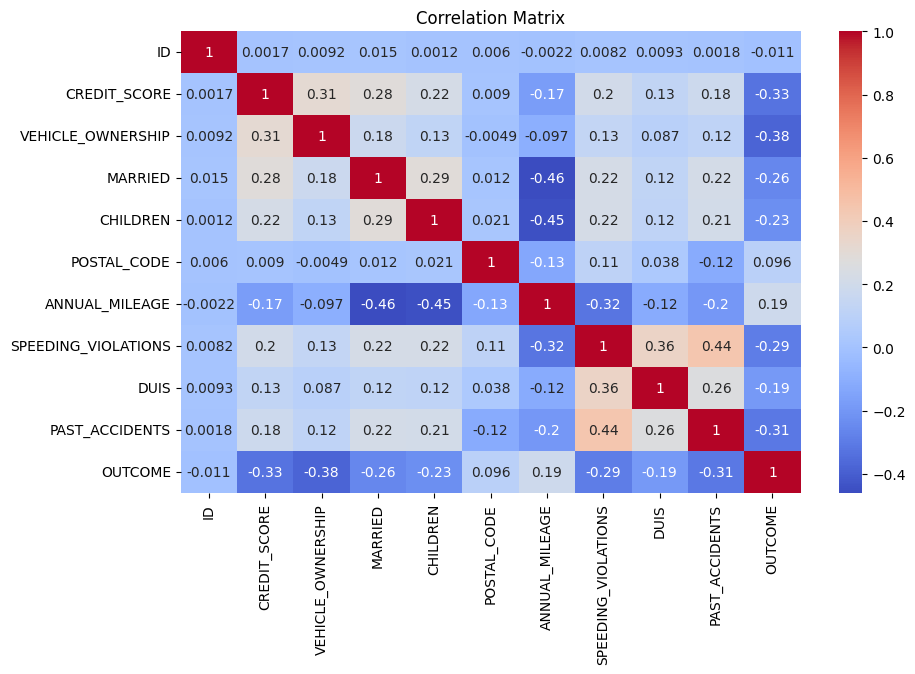

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


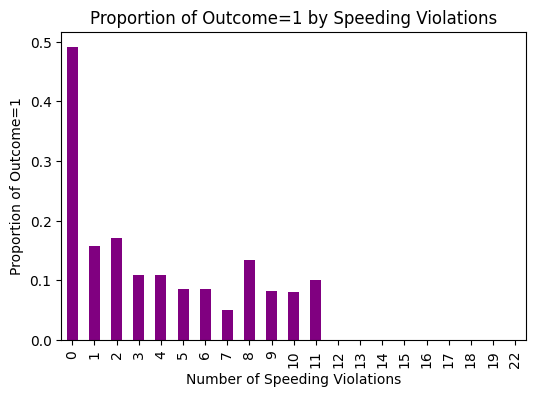

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# حساب النسبة لكل عدد مخالفات
summary = df.groupby('SPEEDING_VIOLATIONS')['OUTCOME'].mean()

plt.figure(figsize=(6,4))
summary.plot(kind='bar', color='purple')
plt.xlabel('Number of Speeding Violations')
plt.ylabel('Proportion of Outcome=1')
plt.title('Proportion of Outcome=1 by Speeding Violations')
plt.show()



Zero speeding violation shows the highest average outcome(1) which is an unusal thing while >7 violation speed tend to show lower average outcome

In [ ]:
# حساب العدد لكل فئة عمرية لكل Outcome
age_counts = df.groupby(['AGE', 'OUTCOME']).size().unstack(fill_value=0)
print(age_counts)


OUTCOME       0.0   1.0
AGE                    
Adult        2031  1032
Middle-aged  2474   457
Old          1794   196
Young         568  1448


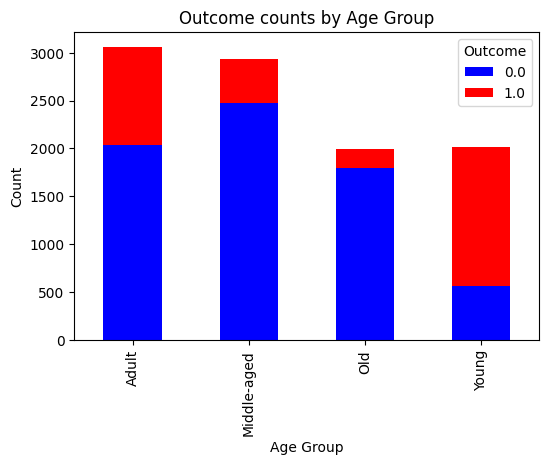

In [ ]:
age_counts.plot(kind='bar', stacked=True, color=['blue','red'], figsize=(6,4))
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Outcome counts by Age Group')
plt.legend(title='Outcome')
plt.show()


- Young people shows the highest counts of outcome=1, while middle_aged (40-64)shows the least number of caliming outcome(1)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_numeric_vs_target(df, x, y='SalePrice', figsize=(6,4), **kwargs): # kwargs for sns.regplot
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]
  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','lw':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})")
  # Make sure the plot is shown before the print statement
  plt.show()
  return fig, ax

In [ ]:
df.head()

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,Old,female,majority,Novice (0-9y),high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,Young,male,majority,Novice (0-9y),none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,Young,female,majority,Novice (0-9y),high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,Young,male,majority,Novice (0-9y),university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,Adult,male,majority,Intermediate (10-19y),none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [ ]:
df['POSTAL_CODE'].unique()

array([10238, 32765, 92101, 21217])

# preprocessing

## train test split

In [ ]:
#define target feature
y = df['OUTCOME']
X = df.drop(columns=['ID','OUTCOME'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## ord cols

In [ ]:
df.head()

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,Old,female,majority,Novice (0-9y),high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,Young,male,majority,Novice (0-9y),none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,Young,female,majority,Novice (0-9y),high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,Young,male,majority,Novice (0-9y),university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,Adult,male,majority,Intermediate (10-19y),none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [ ]:
ord_cols = ["DRIVING_EXPERIENCE",'AGE', 'EDUCATION', 'INCOME' ]
ord1=['Novice (0-9y)', 'Intermediate (10-19y)', 'Experienced (20-29y)',
       'Expert (30y+)']
ord2=['Young', 'Adult', 'Middle-aged', 'Old']
ord3=['none','high school',  'university']
ord4=['poverty','working class', 'middle class','upper class'  ]
ordinal=OrdinalEncoder(categories=[ord1,ord2,ord3,ord4])
scaler=StandardScaler()
impute_missing=SimpleImputer(strategy='most_frequent')
ord_pipe=make_pipeline(impute_missing,ordinal,scaler)
ord_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('ordinalencoder',
                 OrdinalEncoder(categories=[['Novice (0-9y)',
                                             'Intermediate (10-19y)',
                                             'Experienced (20-29y)',
                                             'Expert (30y+)'],
                                            ['Young', 'Adult', 'Middle-aged',
                                             'Old'],
                                            ['none', 'high school',
                                             'university'],
                                            ['poverty', 'working class',
                                             'middle class', 'upper class']])),
                ('standardscaler', StandardScaler())])

In [ ]:
ord_tuple=('ordinal',ord_pipe,ord_cols)

In [ ]:
df['INCOME'].unique()

array(['upper class', 'poverty', 'working class', 'middle class'],
      dtype=object)

## cat cols

In [ ]:
cat_cols=X_train.select_dtypes(include='object').drop(columns=ord_cols).columns
cat_cols

Index(['GENDER', 'RACE', 'VEHICLE_YEAR', 'VEHICLE_TYPE'], dtype='object')

In [ ]:
impute_cat=SimpleImputer(strategy='constant',fill_value='MISSING')
one_hot=OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False)
cat_pipe=make_pipeline(impute_cat,one_hot)
cat_pipe

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='MISSING', strategy='constant')),
                ('onehotencoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])

In [ ]:
cat_tuple=('categorical',cat_pipe,cat_cols)

## num_cols

In [ ]:
num_cols=X_train.select_dtypes(include='number').columns
num_cols

Index(['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN',
       'POSTAL_CODE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS',
       'PAST_ACCIDENTS'],
      dtype='object')

In [ ]:
impute_num=SimpleImputer(strategy='median')
# imputing with median as there are some outliers, so the mean would be affected by
num_pipe=make_pipeline(impute_num,scaler)
num_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [ ]:
df['OUTCOME'].value_counts(normalize=True)

,proportion
OUTCOME,
0.0,0.6867
1.0,0.3133


In [ ]:
num_tuple=('numeric',num_pipe,num_cols)

## col transformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[cat_tuple,ord_tuple,num_tuple],remainder='passthrough',
                                    verbose_feature_names_out=False)
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='MISSING',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['GENDER', 'RACE', 'VEHICLE_YEAR', 'VEHICLE_TYPE'], dtype='object')),
                                ('ordinal',
                                 Pipeline(steps=...
                                 ['DRIVING_EXPERIENCE', 'AGE', 'EDUCATION',
                                  'INCOME']),
                                ('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN',
       'POSTAL_CODE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS',
       'PAST_ACCIDENTS'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [ ]:
X_train_tf=preprocessor.fit_transform(X_train)
X_train_tf.head()

,GENDER_male,RACE_minority,VEHICLE_YEAR_before 2015,VEHICLE_TYPE_sports car,DRIVING_EXPERIENCE,AGE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS
9254,0.0,0.0,0.0,0.0,1.933727,1.466105,-0.279326,0.959008,0.225158,0.661480,0.997004,0.677143,-0.511636,-1.390556,1.111686,-0.433018,2.940435
1561,1.0,0.0,1.0,0.0,-1.078309,-0.478815,-1.633635,-1.655576,-1.184005,-1.511761,0.997004,0.677143,-0.511636,-1.017165,-0.661338,-0.433018,-0.642457
1670,0.0,1.0,1.0,0.0,-1.078309,-0.478815,1.074983,0.087480,0.151632,0.661480,0.997004,-1.476792,-0.511636,0.103009,-0.661338,-0.433018,-0.642457
6087,0.0,0.0,0.0,0.0,-0.074297,0.493645,-0.279326,0.959008,0.740542,0.661480,0.997004,-1.476792,0.685773,-1.017165,0.668430,-0.433018,-0.642457
6669,1.0,0.0,1.0,0.0,-1.078309,0.493645,1.074983,0.087480,-0.321099,0.661480,-1.003005,-1.476792,0.685773,0.476401,-0.661338,-0.433018,-0.642457


In [ ]:
X_test_tf=preprocessor.transform(X_test)
X_test_tf.head()

,GENDER_male,RACE_minority,VEHICLE_YEAR_before 2015,VEHICLE_TYPE_sports car,DRIVING_EXPERIENCE,AGE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS
6252,0.0,0.0,1.0,0.0,-0.074297,-0.478815,-0.279326,0.087480,0.195818,-1.511761,0.997004,0.677143,0.685773,-0.270382,-0.218082,-0.433018,-0.642457
4684,0.0,0.0,1.0,0.0,0.929715,1.466105,-0.279326,0.959008,0.286927,0.661480,0.997004,-1.476792,-0.511636,-1.390556,0.668430,1.346202,1.746137
1731,0.0,1.0,1.0,0.0,-1.078309,-1.451275,-1.633635,-1.655576,-2.075660,-1.511761,-1.003005,-1.476792,0.685773,0.476401,-0.661338,-0.433018,-0.642457
4742,1.0,0.0,1.0,0.0,-1.078309,-1.451275,-1.633635,-1.655576,0.062604,0.661480,-1.003005,-1.476792,-0.511636,0.849792,-0.661338,-0.433018,-0.642457
4521,0.0,0.0,0.0,1.0,0.929715,0.493645,1.074983,0.959008,1.331058,0.661480,0.997004,0.677143,-0.511636,-0.643773,0.225174,-0.433018,-0.642457


In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_tf, y_train)

In [ ]:
y_train_res.value_counts()

,count
OUTCOME,
0.0,5500
1.0,5500


# base line model

In [ ]:
log_model=LogisticRegression(random_state=42)
log_model.fit(X_train_res,y_train_res)

LogisticRegression(random_state=42)

In [ ]:
y_pred = (log_model.predict_proba(X_test_tf)[:,1] > 0.4) #reduce overfiting to handle

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.86      0.81      0.83      5500
         1.0       0.82      0.86      0.84      5500

    accuracy                           0.84     11000
   macro avg       0.84      0.84      0.84     11000
weighted avg       0.84      0.84      0.84     11000



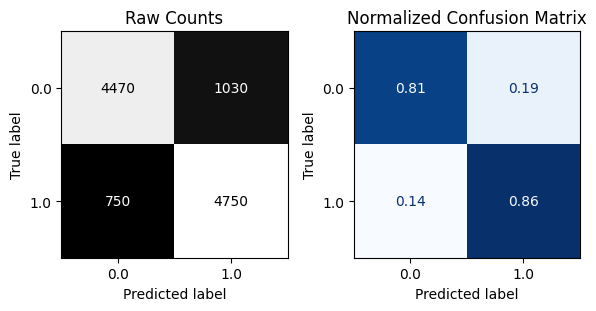


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.91      0.82      0.86      1367
         1.0       0.68      0.83      0.75       633

    accuracy                           0.82      2000
   macro avg       0.80      0.82      0.80      2000
weighted avg       0.84      0.82      0.83      2000



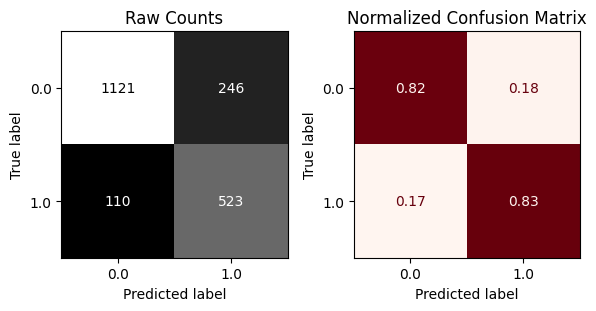

In [ ]:
log_results= evaluate_classification(log_model, X_train_res, y_train_res, X_test_tf, y_test, output_dict=True)

- On the training data, the model achieves 84% accuracy, meaning it correctly classifies 84% of all cases overall.
- Precision of 0.86 for class 0 indicates that when the model predicts class 0, it is correct about 86% of the time, while precision of 0.82 for class 1 means 82% of predicted positive cases are correct.

- Recall of 0.81 for class 0 shows the model successfully identifies 81% of all actual class 0 cases, while recall of 0.86 for class 1 means it correctly captures 86% of all actual class 1 cases.

- The F1-scores (0.83 for class 0 and 0.84 for class 1) indicate a good balance between precision and recall for both classes, showing consistent performance without major trade-offs.

Overall, the macro and weighted averages (~0.84) confirm that the model performs evenly across both classes with no strong bias during training.

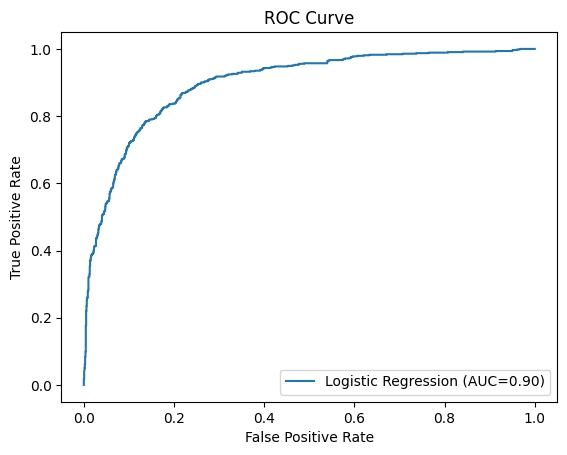

In [ ]:
plot_roc(log_model, X_test_tf, y_test, "Logistic Regression")

### RF_classifier

In [ ]:
rf=RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [ 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_res, y_train_res)

best_rf = grid_search.best_estimator_

print(grid_search.best_params_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      5500
         1.0       0.96      0.98      0.97      5500

    accuracy                           0.97     11000
   macro avg       0.97      0.97      0.97     11000
weighted avg       0.97      0.97      0.97     11000



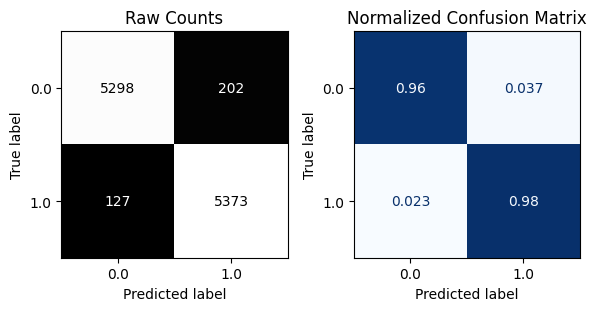


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.88      0.90      0.89      1367
         1.0       0.77      0.74      0.75       633

    accuracy                           0.85      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.85      0.85      0.85      2000



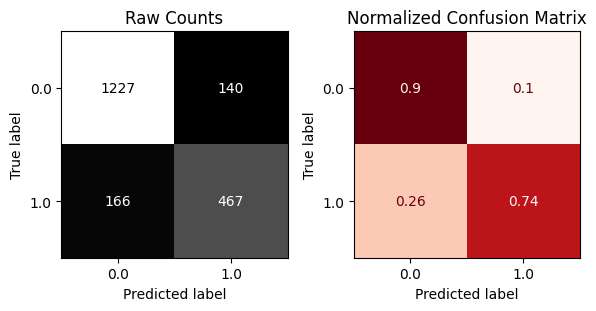

In [ ]:
rf_results= evaluate_classification(best_rf, X_train_res, y_train_res, X_test_tf, y_test, output_dict=True)

- On the training data, the model achieves perfect performance with 100% accuracy, precision, recall, and F1-score for both classes, meaning it classifies all training samples correctly without any errors.

- On the test data, accuracy drops to 83%, indicating that the model correctly predicts 83% of unseen samples, which reflects a gap between training and generalization performance.

- For class 0, precision of 0.87 means that 87% of predicted class 0 cases are correct, while recall of 0.89 indicates the model successfully identifies 89% of all actual class 0 instances.

- For class 1, precision of 0.76 and recall of 0.71 show weaker performance compared to class 0, meaning the model struggles more with correctly identifying and predicting class 1 cases, suggesting a degree of class imbalance or overfitting.

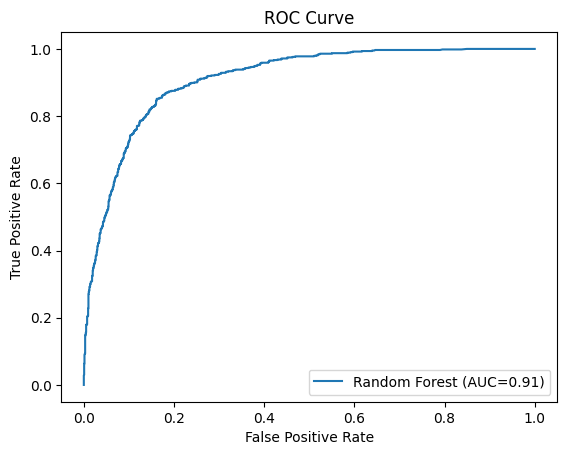

In [ ]:
plot_roc(best_rf, X_test_tf, y_test, "Random Forest")

### decision tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_res, y_train_res)

best_dt = grid_search.best_estimator_

print(grid_search.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.91      0.88      0.89      5500
         1.0       0.88      0.91      0.90      5500

    accuracy                           0.89     11000
   macro avg       0.89      0.89      0.89     11000
weighted avg       0.89      0.89      0.89     11000



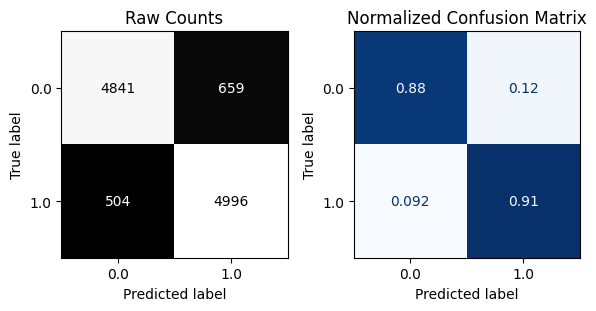


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88      1367
         1.0       0.73      0.77      0.75       633

    accuracy                           0.84      2000
   macro avg       0.81      0.82      0.81      2000
weighted avg       0.84      0.84      0.84      2000



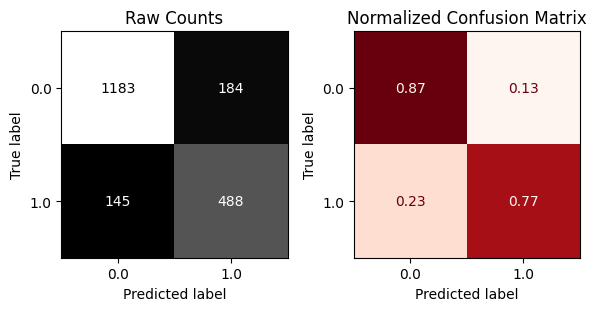

In [ ]:
dt_results=evaluate_classification(
    best_dt,
    X_train_res, y_train_res,
    X_test_tf, y_test, output_dict=True
)

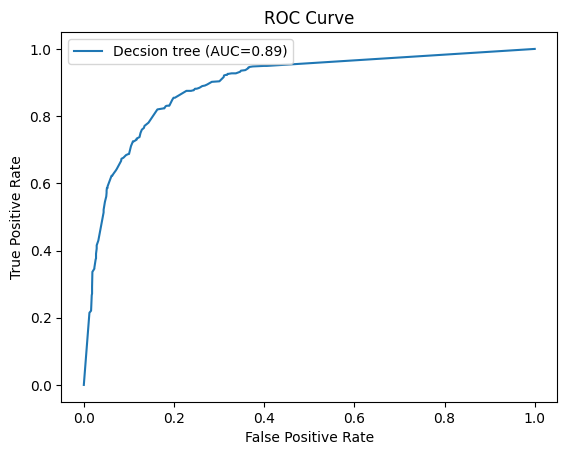

In [ ]:
plot_roc(best_dt, X_test_tf, y_test, "Decsion tree")

### XGboost

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss')

In [ ]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='f1', verbose=1)

In [ ]:
print(grid_search.best_params_)

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}


In [ ]:
best_xgb = grid_search.best_estimator_

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89      5500
         1.0       0.88      0.91      0.89      5500

    accuracy                           0.89     11000
   macro avg       0.89      0.89      0.89     11000
weighted avg       0.89      0.89      0.89     11000



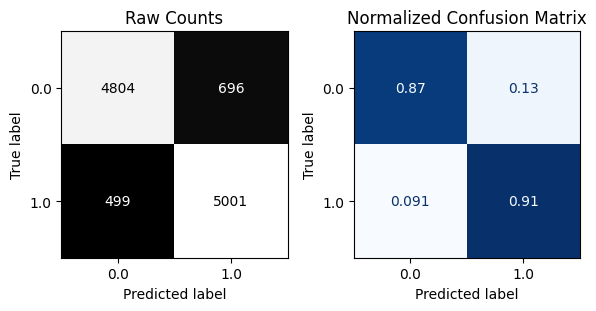


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.90      0.87      0.89      1367
         1.0       0.74      0.79      0.77       633

    accuracy                           0.85      2000
   macro avg       0.82      0.83      0.83      2000
weighted avg       0.85      0.85      0.85      2000



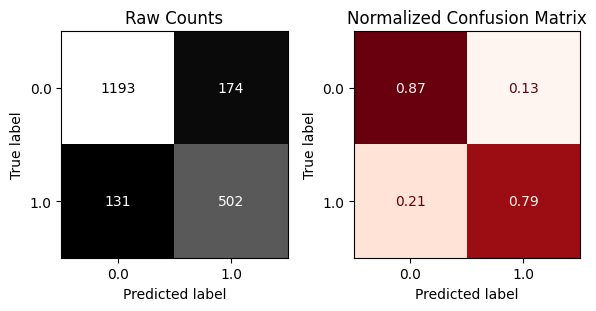

In [ ]:
xgb_results= evaluate_classification(best_xgb, X_train_res, y_train_res, X_test_tf, y_test, output_dict=True)

- On the training data, the model achieves an overall accuracy of 0.89, meaning it correctly classifies 89% of all samples, with balanced performance across both classes. Precision of 0.91 for class 0 indicates that 91% of predicted class 0 cases are correct, while recall of 0.87 means the model correctly identifies 87% of all actual class 0 instances.

- For class 1, precision of 0.88 shows that 88% of predicted positive cases are correct, while recall of 0.91 indicates the model successfully captures 91% of all actual class 1 cases, showing strong sensitivity to the positive class.

- On the test data, accuracy drops slightly to 0.85, indicating good generalization but some loss of performance on unseen data. Precision of 0.90 for class 0 and 0.74 for class 1 shows the model is much more reliable when predicting class 0 than class 1.

Similarly, recall of 0.87 for class 0 versus 0.80 for class 1 shows the model identifies class 0 more consistently, suggesting a moderate class imbalance in performance on unseen data.

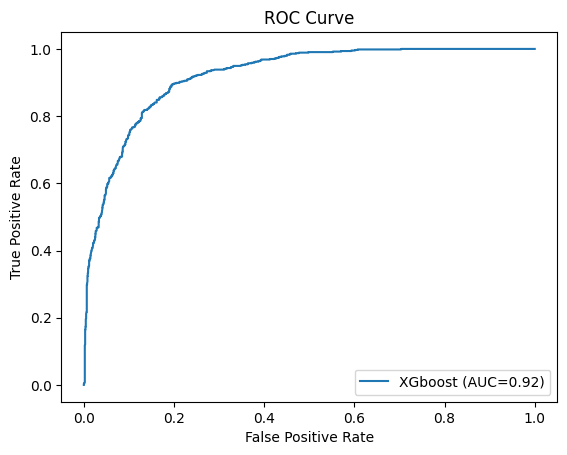

In [ ]:
plot_roc(best_xgb, X_test_tf, y_test, "XGboost")

In [ ]:
!pip install shap

### Naive bayes

In [ ]:
nb = GaussianNB()

param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_search = GridSearchCV(
    estimator=nb,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res)

best_nb = grid_search.best_estimator_

print(grid_search.best_params_)

{'var_smoothing': 1e-09}


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.82      0.75      0.78      5500
         1.0       0.77      0.84      0.80      5500

    accuracy                           0.79     11000
   macro avg       0.79      0.79      0.79     11000
weighted avg       0.79      0.79      0.79     11000



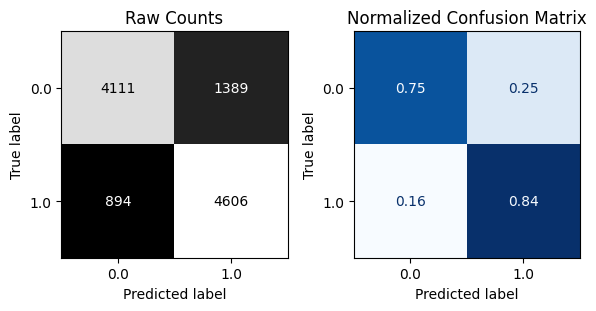


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.89      0.76      0.82      1367
         1.0       0.61      0.80      0.69       633

    accuracy                           0.77      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.80      0.77      0.78      2000



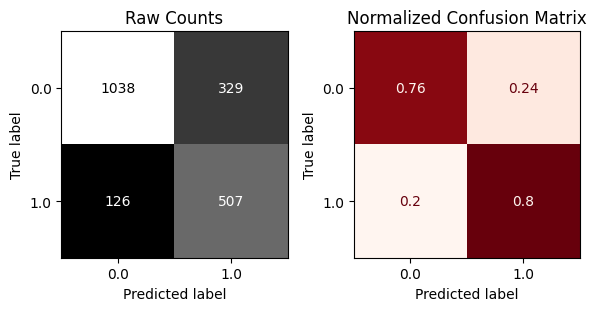

In [ ]:
nb_results= evaluate_classification(
    best_nb,
    X_train_res, y_train_res,
    X_test_tf, y_test, output_dict=True

)

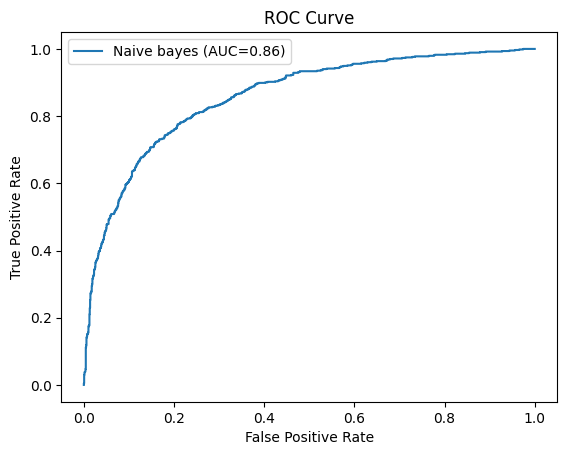

In [ ]:
plot_roc(best_nb, X_test_tf, y_test, "Naive bayes")

### SVM

In [ ]:
svm = SVC(probability=True, random_state=42)

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_res, y_train_res)

best_svm = grid_search.best_estimator_

print(grid_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.93      0.87      0.90      5500
         1.0       0.88      0.94      0.91      5500

    accuracy                           0.90     11000
   macro avg       0.91      0.90      0.90     11000
weighted avg       0.91      0.90      0.90     11000



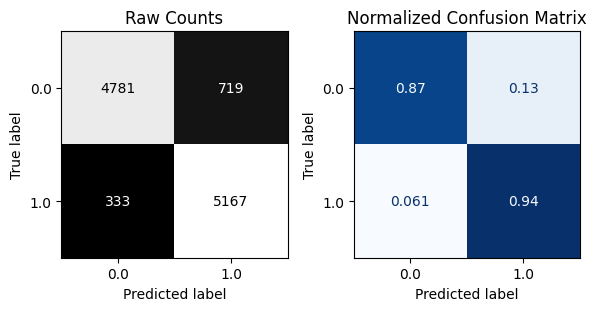


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.90      0.85      0.87      1367
         1.0       0.71      0.80      0.75       633

    accuracy                           0.83      2000
   macro avg       0.81      0.82      0.81      2000
weighted avg       0.84      0.83      0.84      2000



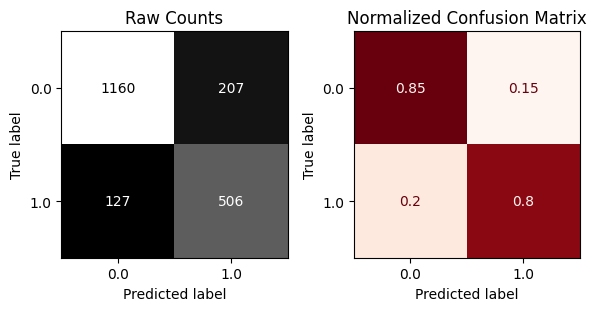

In [ ]:
svm_results= evaluate_classification(
    best_svm,
    X_train_res, y_train_res,
    X_test_tf, y_test, output_dict=True
)

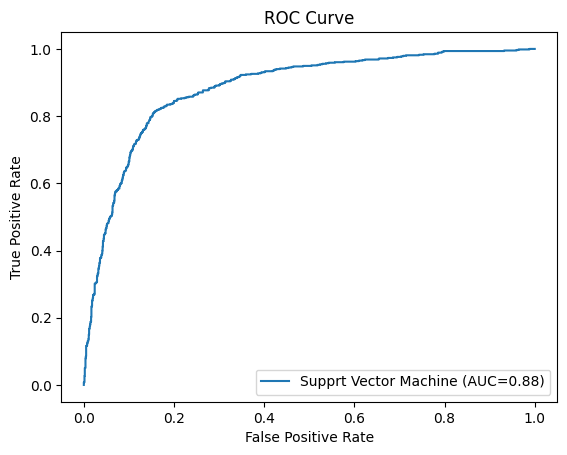

In [ ]:
plot_roc(best_svm, X_test_tf, y_test, "Supprt Vector Machine")

In [ ]:
def extract_metrics(result):
    return {
        "Accuracy": result["test"]["accuracy"],
        "Precision": result["test"]["weighted avg"]["precision"],
        "Recall": result["test"]["weighted avg"]["recall"],
        "F1-score": result["test"]["weighted avg"]["f1-score"]
    }

In [ ]:
results_df = pd.DataFrame([
    {"Model": "Logistic Regression", **extract_metrics(log_results)},
    {"Model": "Decision Tree", **extract_metrics(dt_results)},
    {"Model": "Random Forest", **extract_metrics(rf_results)},
    {"Model": "Naive Bayes", **extract_metrics(nb_results)},
    {"Model": "SVM", **extract_metrics(svm_results)},
    {"Model": "XGBoost", **extract_metrics(xgb_results)},
])

In [ ]:
results_df.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score
5,XGBoost,0.8475,0.850907,0.8475,0.848786
2,Random Forest,0.8470,0.845551,0.8470,0.846117
1,Decision Tree,0.8355,0.838710,0.8355,0.836768
4,SVM,0.8330,0.840666,0.8330,0.835446
0,Logistic Regression,0.8220,0.837677,0.8220,0.825974
3,Naive Bayes,0.7725,0.801457,0.7725,0.779096


In [ ]:
print(log_results)

{'train': {'0.0': {'precision': 0.8563218390804598, 'recall': 0.8127272727272727, 'f1-score': 0.8339552238805971, 'support': 5500.0}, '1.0': {'precision': 0.8217993079584776, 'recall': 0.8636363636363636, 'f1-score': 0.8421985815602837, 'support': 5500.0}, 'accuracy': 0.8381818181818181, 'macro avg': {'precision': 0.8390605735194687, 'recall': 0.8381818181818181, 'f1-score': 0.8380769027204404, 'support': 11000.0}, 'weighted avg': {'precision': 0.8390605735194686, 'recall': 0.8381818181818181, 'f1-score': 0.8380769027204404, 'support': 11000.0}}, 'test': {'0.0': {'precision': 0.9106417546709992, 'recall': 0.8200438917337235, 'f1-score': 0.8629715165511932, 'support': 1367.0}, '1.0': {'precision': 0.6801040312093628, 'recall': 0.8262243285939969, 'f1-score': 0.746077032810271, 'support': 633.0}, 'accuracy': 0.822, 'macro avg': {'precision': 0.795372892940181, 'recall': 0.8231341101638602, 'f1-score': 0.8045242746807322, 'support': 2000.0}, 'weighted avg': {'precision': 0.837676565195391

# streamlit interface

In [ ]:
import pickle

pickle.dump(preprocessor, open("preprocessor.pkl", "wb"))

# Saving models

In [ ]:
import joblib
import os

In [ ]:
#create folder to save models at
os.makedirs('models',exist_ok=True)

# Saving models
joblib.dump(best_rf,'models/random_forest.pkl')
joblib.dump(best_dt,'models/Decision_tree.pkl')
joblib.dump(best_nb,'models/naive_bayes.pkl')
joblib.dump(best_svm,'models/support_vector_machine.pkl')
joblib.dump(best_xgb,'models/XGboost.pkl')

#saving preprocessor
joblib.dump(preprocessor,'models/preprocessor.pkl')
print('preprocessor and models has been saved successfully')

preprocessor and models has been saved successfully


In [ ]:
import shap

In [ ]:
explainer = shap.Explainer(best_xgb)

In [ ]:
shap_values = explainer(X_test_tf) #calcuate shap values

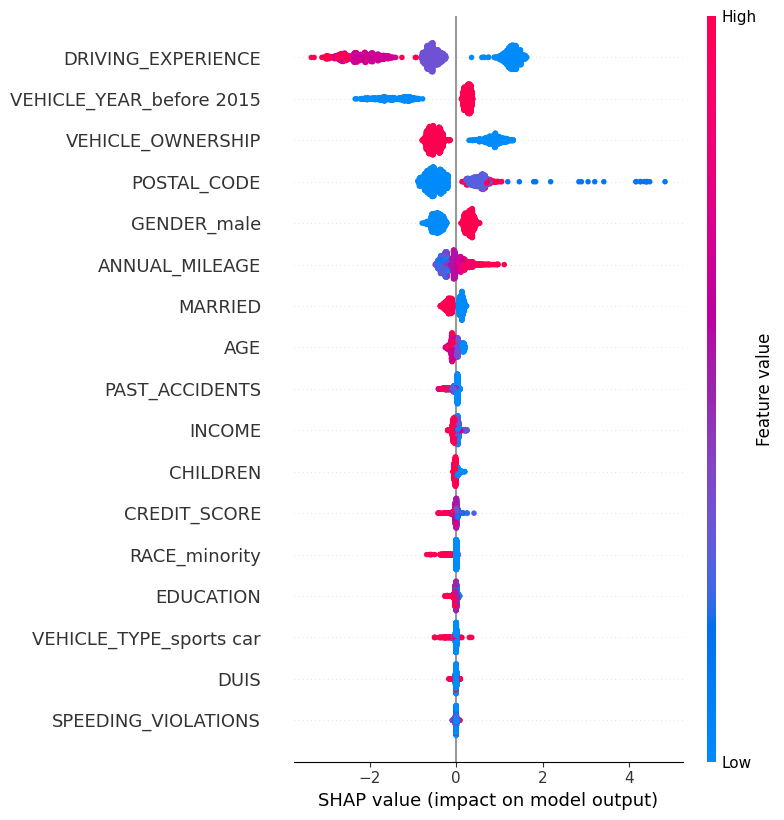

In [ ]:
shap.summary_plot(shap_values, X_test_tf)

The SHAP plot shows that DRIVING_EXPERIENCE is the top predictor, with lower experience strongly driving higher model outputs. Conversely, owning an older car or lacking vehicle ownership increases the risk prediction, while bottom features have negligible impact.

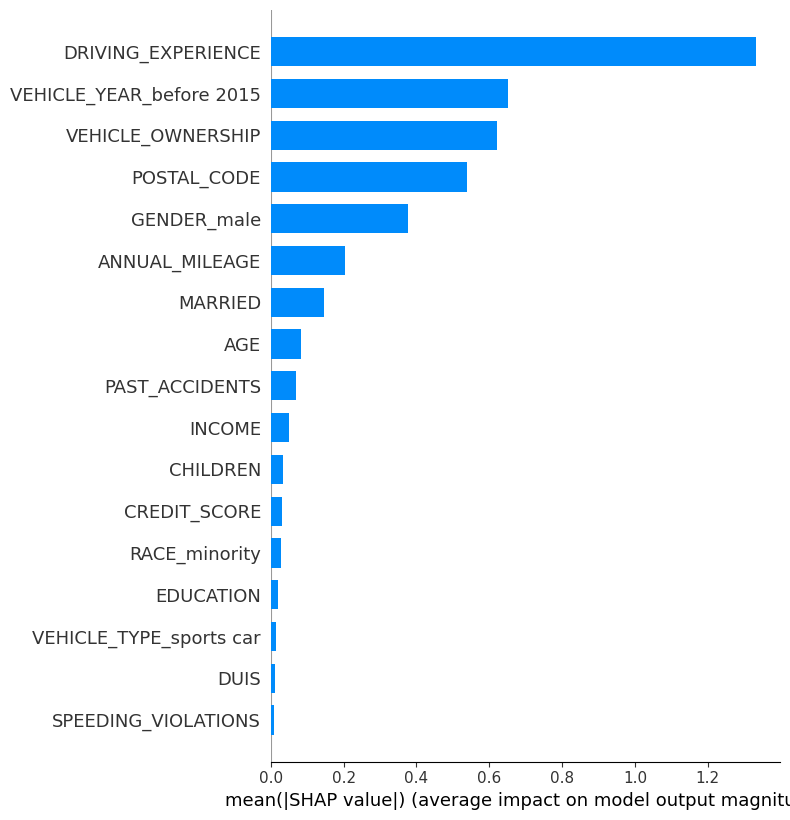

In [ ]:
shap.summary_plot(shap_values, X_test_tf, plot_type="bar")

The SHAP bar plot confirms that DRIVING_EXPERIENCE has the highest global importance, followed by VEHICLE_YEAR_before_2015 and VEHICLE_OWNERSHIP as the primary drivers of the model's predictions.

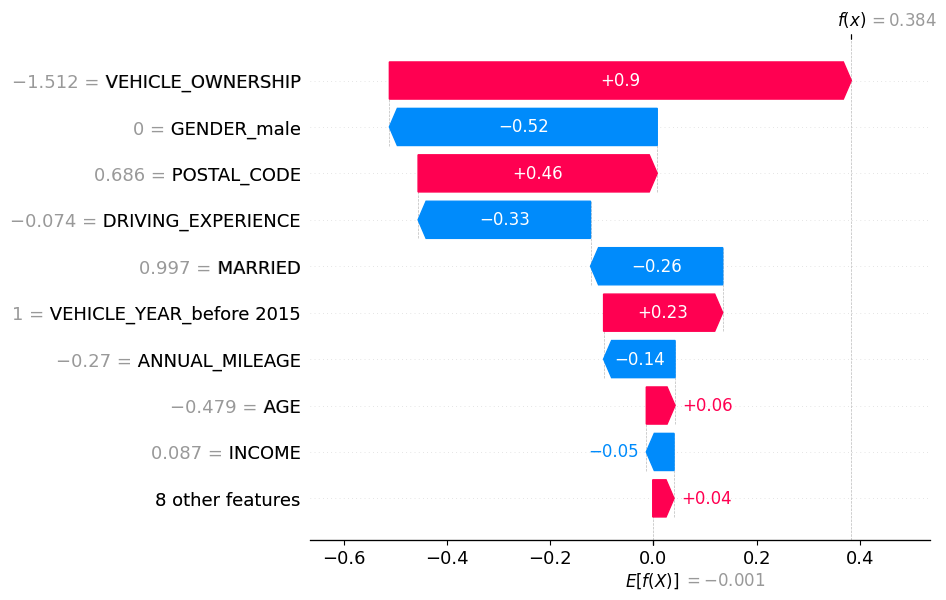

In [ ]:
shap.plots.waterfall(shap_values[0])

The SHAP waterfall plot explains a single prediction, where VEHICLE_OWNERSHIP and POSTAL_CODE push the output higher, while GENDER_male and DRIVING_EXPERIENCE pull it down, resulting in a final prediction of 0.444 from the baseline.

# model comparsion table

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def get_results(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (file a claim)": precision_score(y_test, y_pred),
        "Recall (file a claim)": recall_score(y_test, y_pred),
        "F1-score (file a claim)": f1_score(y_test, y_pred)
    }

In [ ]:
results = []

#results.append(get_results(log_model, X_test_tf, y_test, "Logistic Regression"))
results.append(get_results(best_rf, X_test_tf, y_test, "Random Forest"))
results.append(get_results(best_svm, X_test_tf, y_test, "SVM"))
results.append(get_results(best_xgb, X_test_tf, y_test, "Tuned XGBoost"))
results.append(get_results(best_nb, X_test_tf, y_test, "Naive bayes"))
results.append(get_results(best_dt, X_test_tf, y_test, "Decision tree"))

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (file a claim),Recall (file a claim),F1-score (file a claim)
0,Random Forest,0.8470,0.769357,0.737757,0.753226
1,SVM,0.8330,0.709677,0.799368,0.751857
2,Tuned XGBoost,0.8475,0.742604,0.793049,0.766998
3,Naive bayes,0.7725,0.606459,0.800948,0.690265
4,Decision tree,0.8355,0.726190,0.770932,0.747893
